In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
path = "/content/gdrive/MyDrive/Colab Notebooks/"
import sys; sys.path.append(path+'lib')
from variable_print import p,ps,pst

In [ ]:
import numpy as np
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
import random

# DDPG 실습

https://www.gymlibrary.dev/environments/mujoco/


## Pendulum Environment

https://www.gymlibrary.dev/environments/classic_control/pendulum/

In [ ]:
# env = gym.make("Pendulum-v1")
import gymnasium as gym
env = gym.make("Pendulum-v1", render_mode="rgb_array")

num_states = env.observation_space.shape[0]
print("Size of State Space ->  {}".format(num_states))
num_actions = env.action_space.shape[0]
print("Size of Action Space ->  {}".format(num_actions))

upper_bound = env.action_space.high[0]
lower_bound = env.action_space.low[0]

print("Max Value of Action ->  {}".format(upper_bound))
print("Min Value of Action ->  {}".format(lower_bound))

Size of State Space ->  3
Size of Action Space ->  1
Max Value of Action ->  2.0
Min Value of Action ->  -2.0


In [ ]:
gamma = 0.99
tau = 0.005
critic_lr = 0.002
actor_lr = 0.001
buffer_capacity = 50000
batch_size = 64
total_episodes = 100

## Ornstein-Uhlenbeck process에 따라 Noise 계산  

In [ ]:
class OUActionNoise:
    def __init__(self, mean, std_deviation, theta=0.15, dt=1e-2, x_initial=None):
        self.theta = theta
        self.mean = mean
        self.std_dev = std_deviation
        self.dt = dt
        self.x_initial = x_initial
        self.reset()

    def __call__(self):
        x = (
            self.x_prev
            + self.theta * (self.mean - self.x_prev) * self.dt
            + self.std_dev * np.sqrt(self.dt) * np.random.normal(size=self.mean.shape)
        )
        self.x_prev = x
        return x

    def reset(self):
        if self.x_initial is not None:
            self.x_prev = self.x_initial
        else:
            self.x_prev = np.zeros_like(self.mean)


## Actor-Network, Critic-Network

In [ ]:
class Actor(nn.Module):
    def __init__(self):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(num_states, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, num_actions)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # 마지막 레이어의 가중치와 편향을 작게 초기화 (DDPG 논문 기법)
        # 여기서는 모델 생성 후 직접 초기화
        x = torch.tanh(self.fc3(x)) * upper_bound
        return x

class Critic(nn.Module):
    def __init__(self):
        super(Critic, self).__init__()
        # State 경로
        self.state_fc1 = nn.Linear(num_states, 16)
        self.state_fc2 = nn.Linear(16, 32)
        # Action 경로
        self.action_fc = nn.Linear(num_actions, 32)
        # 결합 경로
        self.concat_fc1 = nn.Linear(64, 256)
        self.concat_fc2 = nn.Linear(256, 256)
        self.output_fc = nn.Linear(256, 1)

    def forward(self, state, action):
        state_out = F.relu(self.state_fc1(state))
        state_out = F.relu(self.state_fc2(state_out))
        action_out = F.relu(self.action_fc(action))
        concat = torch.cat([state_out, action_out], dim=1)
        out = F.relu(self.concat_fc1(concat))
        out = F.relu(self.concat_fc2(out))
        q_value = self.output_fc(out)
        return q_value


## DDPG Agent

In [ ]:
class DDPGAgent:
    def __init__(self):
        self.actor = Actor()
        self.critic = Critic()
        self.target_actor = Actor()
        self.target_critic = Critic()

        # Target 네트워크 가중치를 메인 네트워크와 동일하게 초기화
        self.target_actor.load_state_dict(self.actor.state_dict())
        self.target_critic.load_state_dict(self.critic.state_dict())

        # Optimizer 설정
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=critic_lr)

        # Replay Buffer
        self.buffer = deque(maxlen=buffer_capacity)

        # Noise 객체
        self.noise = OUActionNoise(mean=np.zeros(1), std_deviation=float(0.2) * np.ones(1))

    def record(self, obs_tuple):
        self.buffer.append(obs_tuple)

    def learn(self):
        if len(self.buffer) < batch_size:
            return

        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states = map(np.array, zip(*batch))

        states = torch.FloatTensor(states)
        actions = torch.FloatTensor(actions)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(next_states)

        # --- Critic 학습 ---
        with torch.no_grad():
            target_actions = self.target_actor(next_states)
            y = rewards + gamma * self.target_critic(next_states, target_actions)

        critic_value = self.critic(states, actions)
        critic_loss = F.mse_loss(critic_value, y)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # --- Actor 학습 ---
        actor_loss = -self.critic(states, self.actor(states)).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

    def update_target(self):
        # Soft update
        for target_param, param in zip(self.target_actor.parameters(), self.actor.parameters()):
            target_param.data.copy_(tau * param.data + (1.0 - tau) * target_param.data)

        for target_param, param in zip(self.target_critic.parameters(), self.critic.parameters()):
            target_param.data.copy_(tau * param.data + (1.0 - tau) * target_param.data)

    def policy(self, state):
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            sampled_action = self.actor(state_tensor).squeeze(0).numpy()

        noise = self.noise()
        sampled_action = sampled_action + noise
        legal_action = np.clip(sampled_action, lower_bound, upper_bound)

        return [np.squeeze(legal_action)]

## Training hyperparameters

In [ ]:
std_dev = 0.2
ou_noise = OUActionNoise(mean=np.zeros(1), std_deviation=float(std_dev) * np.ones(1))

gamma = 0.99
tau = 0.005

## Training Loop  
`policy()` : action sampling  
`learn()` :  train each step  
`update_target()` : TragetNetwork update  

In [ ]:
%%time
total_episodes = 100

agent = DDPGAgent()
ep_reward_list = []
avg_reward_list = []

print("학습을 시작합니다...")
for ep in range(total_episodes):
    prev_state, info = env.reset()
    episodic_reward = 0

    while True:
        action = agent.policy(prev_state)
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        agent.record((prev_state, action, reward, state))
        episodic_reward += reward

        agent.learn()
        agent.update_target()

        prev_state = state

        if done:
            break

    ep_reward_list.append(episodic_reward)
    avg_reward = np.mean(ep_reward_list[-10:])
    print(f"Episode * {ep} * Avg Reward is ==> {avg_reward:.2f}")
    avg_reward_list.append(avg_reward)

env.close()
print("학습 종료!")


학습을 시작합니다...
Episode * 0 * Avg Reward is ==> -1350.52
Episode * 1 * Avg Reward is ==> -1367.77
Episode * 2 * Avg Reward is ==> -1392.53
Episode * 3 * Avg Reward is ==> -1464.85
Episode * 4 * Avg Reward is ==> -1505.21
Episode * 5 * Avg Reward is ==> -1533.44
Episode * 6 * Avg Reward is ==> -1479.47
Episode * 7 * Avg Reward is ==> -1476.54
Episode * 8 * Avg Reward is ==> -1450.99
Episode * 9 * Avg Reward is ==> -1428.05
Episode * 10 * Avg Reward is ==> -1397.66
Episode * 11 * Avg Reward is ==> -1367.59
Episode * 12 * Avg Reward is ==> -1373.37
Episode * 13 * Avg Reward is ==> -1337.52
Episode * 14 * Avg Reward is ==> -1273.00
Episode * 15 * Avg Reward is ==> -1226.37
Episode * 16 * Avg Reward is ==> -1202.45
Episode * 17 * Avg Reward is ==> -1133.05
Episode * 18 * Avg Reward is ==> -1094.55
Episode * 19 * Avg Reward is ==> -1057.38
Episode * 20 * Avg Reward is ==> -1003.54
Episode * 21 * Avg Reward is ==> -944.99
Episode * 22 * Avg Reward is ==> -833.47
Episode * 23 * Avg Reward is ==> 

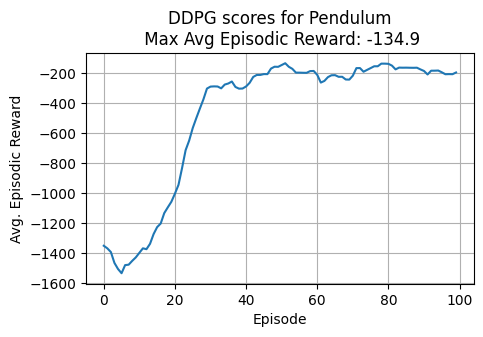

In [ ]:
plt.figure(figsize=(5, 3))
plt.plot(avg_reward_list)
plt.title(f"DDPG scores for Pendulum\n Max Avg Episodic Reward: {max(avg_reward_list):.1f}")
plt.xlabel("Episode")
plt.ylabel("Avg. Episodic Reward")
plt.grid()
plt.show()


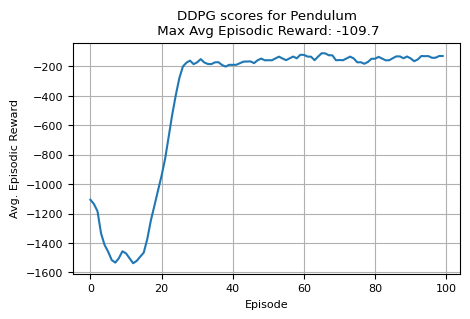

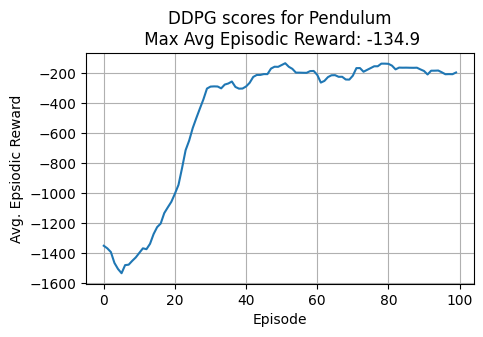

In [ ]:
plt.figure(figsize=(5,3))
name = 'DDPG scores for Pendulum'
plt.title(f"{name}\n Max Avg Episodic Reward: {max(avg_reward_list):.1f}")
plt.plot(avg_reward_list)
plt.xlabel("Episode")
plt.ylabel("Avg. Epsiodic Reward")
plt.grid()
plt.show()

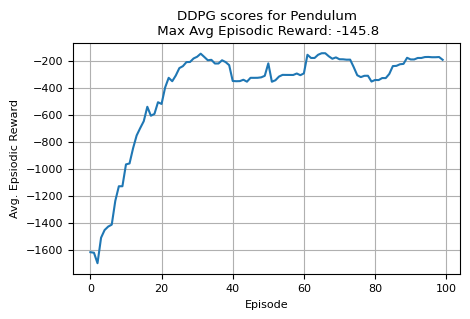

In [ ]:
# Save the weights
# actor_model.save_weights(path+"models/DRL/pendulum_actor.keras")
# actor_model.load_weights(path+"models/DRL/pendulum_actor.keras")

## Evaluation  

In [ ]:
%%time
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

CPU times: user 1.85 s, sys: 328 ms, total: 2.18 s
Wall time: 16.5 s


In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
#path =path+"temp/" ####
env_v = wrap_env(env, path=path, name_prefix="DDPG_pendulum")

/usr/local/lib/python3.11/dist-packages/gymnasium/wrappers/rendering.py:296: UserWarning: WARN: Overwriting existing videos at /content/gdrive/MyDrive/Colab Notebooks/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


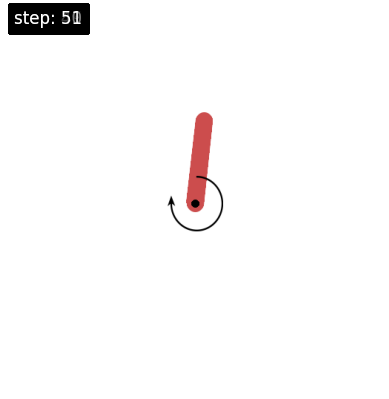

In [ ]:
state, _ = env_v.reset()
cnt = 0
while True:
    render_as_image(env_v,step=cnt)
    action = agent.policy(state)
    state, reward, done, info, _ = env_v.step(action)
    if done or cnt > 50:  break;
    cnt += 1
env_v.close()

In [ ]:
show_video(path=path,name_prefix='DDPG_pendulum')

/content/gdrive/MyDrive/Colab Notebooks/video/DDPG_pendulum-episode-1.mp4


In [ ]:
show_video(path=path,name_prefix='DDPG_pendulum')

/content/gdrive/MyDrive/Colab Notebooks/temp/video/DDPG-episode-0.mp4


# 실습과제   
## 1) Hyper Parameter tuning해 보자  
## 2) 가장 좋은 조건으로 5회 반복하여 변동성을 확인해 보자  

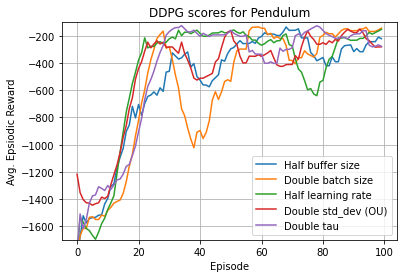

## 실험 1

## Training hyperparameters

In [ ]:
std_dev = 0.2
ou_noise = OUActionNoise(mean=np.zeros(1), std_deviation=float(std_dev) * np.ones(1))

gamma = 0.99
tau = 0.005  ##

## Actor,Critic,Agent Instanciation

In [ ]:
critic_lr = 0.002 ##
actor_lr = 0.001  ##

actor_model = get_actor()
critic_model = get_critic()
target_actor = get_actor()
target_critic = get_critic()
# Traget model weigth <- Main model weight
target_actor.set_weights(actor_model.get_weights())
target_critic.set_weights(critic_model.get_weights())
# Optimizer
critic_optimizer = tf.keras.optimizers.Adam(critic_lr)
actor_optimizer = tf.keras.optimizers.Adam(actor_lr)

agent = DDPG_Agent(2000, 64)  ##

## Training Loop  
`policy()` : action sampling  
`learn()` :  train each step  
`update_target()` : TragetNetwork update  

In [ ]:
%%time
ep_reward_list = []
avg_reward_list = []
total_episodes = 100

for ep in range(total_episodes):
    prev_state = env.reset()
    episodic_reward = 0
    while True:
        tf_prev_state = tf.expand_dims(tf.convert_to_tensor(prev_state), 0)

        action = policy(tf_prev_state, ou_noise)
        state, reward, done, info = env.step(action)
        agent.record((prev_state, action, reward, state))
        episodic_reward += reward

        agent.learn()
        update_target(target_actor.variables, actor_model.variables, tau)
        update_target(target_critic.variables, critic_model.variables, tau)

        if done: break
        prev_state = state
    ep_reward_list.append(episodic_reward)

    avg_reward = np.mean(ep_reward_list[-10:])
    print("Episode * {} * Avg Reward is ==> {}".format(ep, avg_reward))
    avg_reward_list.append(avg_reward)

In [ ]:
plt.plot(avg_reward_list)
plt.title('DDPG scores for Pendulum')
plt.xlabel("Episode")
plt.ylabel("Avg. Epsiodic Reward")
plt.grid()
plt.show()

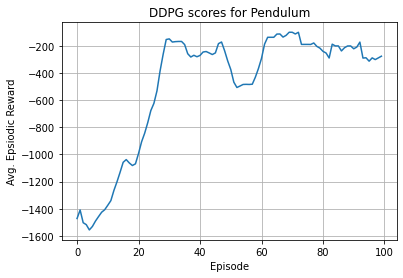